In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import *


In [266]:
from io import BytesIO
import joblib
import zlib

with open("Minimum_Feature_25_Dataset_Uniform_Continuous_SDF_Processed_Dataset/batch_1.pkl", "rb") as f:
    d0 = joblib.load(BytesIO(zlib.decompress(f.read())))
    

with open("Minimum_Feature_25_Dataset_Test_New_Processed/25_145_coords.pkl", "rb") as f:
    d0t = joblib.load(BytesIO((f.read())))


with open("Specific_Type_Polygon_Test_25_Processed/anchor_0_coords.pkl", "rb") as f:
    d0t2 = joblib.load(BytesIO((f.read())))
(d0t)

{'level_2_polygon': array([[1.806, 2.   ],
        [0.849, 1.766],
        [0.52 , 1.704],
        [0.67 , 1.555],
        [0.696, 1.321],
        [0.494, 1.4  ],
        [0.341, 1.037],
        [0.195, 0.974],
        [0.   , 0.702],
        [0.34 , 0.679],
        [0.134, 0.34 ],
        [0.427, 0.377],
        [0.801, 0.2  ],
        [1.258, 0.053],
        [1.489, 0.15 ],
        [1.704, 0.2  ],
        [1.885, 0.   ],
        [1.936, 0.39 ],
        [1.961, 0.757],
        [1.777, 1.238],
        [2.   , 1.378],
        [1.827, 1.549],
        [1.666, 1.621],
        [1.801, 1.704],
        [1.778, 1.816]]),
 'level_2_visibility': array([[1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 1., 0., 1.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 1., 1., 1., 1., 1., 1., 1.],


In [ ]:
def create_polygon_batch(folder_path):
    polygons_pkl_files = os.listdir(folder_path)
    polygon_batch = {}
    for i in polygons_pkl_files:
        with open(os.path.join(folder_path, i), "rb") as f:
            polygon_batch[i] = joblib.load(BytesIO(f.read()))
    return polygon_batch

test_batch1 = create_polygon_batch("Specific_Type_Polygon_Test_25_Processed")
test_batch2 = create_polygon_batch("Minimum_Feature_25_Dataset_Test_New_Processed")


In [259]:
(d0t2.keys())

d0t2

{'level_2_polygon': array([[0.        , 0.        ],
        [0.32515047, 0.38633785],
        [0.65060388, 0.77253694],
        [0.97745382, 1.15809401],
        [1.44225414, 1.45684918],
        [2.        , 1.65065533],
        [1.92935256, 1.68908645],
        [1.86623645, 1.7340853 ],
        [1.80815206, 1.7826301 ],
        [1.75597303, 1.83469508],
        [1.70462831, 1.88720927],
        [1.66100463, 1.94339259],
        [1.61840084, 2.        ],
        [1.40935465, 1.88264276],
        [1.21440077, 1.75920403],
        [1.03353918, 1.62968382],
        [0.8667699 , 1.49408212],
        [0.71409293, 1.35239894],
        [0.57550825, 1.20463427],
        [0.45101588, 1.05078811],
        [0.34061581, 0.89086047],
        [0.24430804, 0.72485135],
        [0.16209258, 0.55276074],
        [0.09396942, 0.37458865],
        [0.03993856, 0.19033507]]),
 'level_2_visibility': array([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1

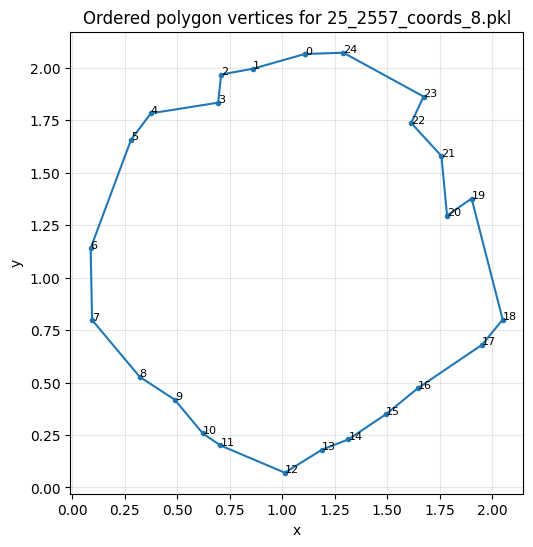

In [273]:
import numpy as np

k = list(d0.keys())[43]
polygon = d0[k]["level_2_polygon"]
closed_polygon = np.vstack([polygon, polygon[0]])


plt.figure(figsize=(6, 6))
plt.plot(closed_polygon[:, 0], closed_polygon[:, 1], "-o", markersize=3)
for idx, (x, y) in enumerate(polygon):
    plt.text(x, y, str(idx), fontsize=8)
plt.gca().set_aspect("equal")
plt.title(f"Ordered polygon vertices for {k}")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
from io import BytesIO
import joblib
import zlib

## Each batch_*.pkl file in this dataset is a zlib-compressed joblib dictionary.
## level_2_polygon has shape (25, 2): each row is one polygon vertex in boundary order.
## The polygon is formed by connecting vertex i to vertex i+1, and the last vertex back to the first.


with open("Minimum_Feature_25_Dataset_Uniform_Continuous_SDF_Processed_Dataset/batch_0.pkl", "rb") as f:
    polygon_dict = joblib.load(BytesIO(zlib.decompress(f.read())))

sample_key = list(polygon_dict)[0]
sample_polygon = polygon_dict[sample_key]["level_2_polygon"]
sample_polygon[:5], sample_polygon.shape

(array([[1.751, 1.249],
        [1.594, 1.506],
        [1.44 , 0.973],
        [1.002, 1.547],
        [1.973, 1.7  ]]),
 (25, 2))

In [ ]:
## Polygon Refactor to Grid

from collections import deque
from heapq import heappop, heappush
from PIL import Image, ImageDraw

def _connected_components(free_mask):
    rows, cols = free_mask.shape
    seen = np.zeros_like(free_mask, dtype=bool)
    components = []

    for row in range(rows):
        for col in range(cols):
            if not free_mask[row, col] or seen[row, col]:
                continue
            queue = deque([(row, col)])
            seen[row, col] = True
            component = []

            while queue:
                curr_row, curr_col = queue.popleft()
                component.append((curr_row, curr_col))
                for d_row, d_col in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                    next_row, next_col = curr_row + d_row, curr_col + d_col
                    if 0 <= next_row < rows and 0 <= next_col < cols and free_mask[next_row, next_col] and not seen[next_row, next_col]:
                        seen[next_row, next_col] = True
                        queue.append((next_row, next_col))

            components.append(component)

    return sorted(components, key=len, reverse=True)

def _shortest_bridge_path(cost_grid, source_cells, target_cells):
    rows, cols = cost_grid.shape
    target_set = set(target_cells)
    heap = []
    best_cost = {}
    parent = {}

    for row, col in source_cells:
        best_cost[(row, col)] = 0.0
        parent[(row, col)] = None
        heappush(heap, (0.0, row, col))

    while heap:
        curr_cost, row, col = heappop(heap)
        if curr_cost > best_cost[(row, col)]:
            continue
        if (row, col) in target_set:
            path = []
            node = (row, col)
            while node is not None:
                path.append(node)
                node = parent[node]
            path.reverse()
            return path, curr_cost

        for d_row, d_col in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            next_row, next_col = row + d_row, col + d_col
            if not (0 <= next_row < rows and 0 <= next_col < cols):
                continue
            next_cost = curr_cost + cost_grid[next_row, next_col]
            next_node = (next_row, next_col)
            if next_cost < best_cost.get(next_node, float('inf')):
                best_cost[next_node] = next_cost
                parent[next_node] = (row, col)
                heappush(heap, (next_cost, next_row, next_col))

    raise RuntimeError('Could not connect free-space components')

def _enforce_free_space_connectivity(grid, coverage):
    connected_grid = grid.copy()
    free_mask = connected_grid == 0
    components = _connected_components(free_mask)
    if len(components) <= 1:
        return connected_grid

    cost_grid = np.where(connected_grid == 0, 0.0, 1.0 - coverage + 1e-6)

    while len(components) > 1:
        base_component = components[0]
        best_path = None
        best_path_cost = float('inf')

        for other_component in components[1:]:
            path, path_cost = _shortest_bridge_path(cost_grid, base_component, other_component)
            if path_cost < best_path_cost:
                best_path = path
                best_path_cost = path_cost

        for row, col in best_path:
            connected_grid[row, col] = 0
            cost_grid[row, col] = 0.0

        free_mask = connected_grid == 0
        components = _connected_components(free_mask)

    return connected_grid

def polygon_to_obstacle_grid(shell, grid_shape=(64, 64), holes=None, samples_per_cell=4, padding_frac=0.08, ensure_connected=True):
    shell = np.asarray(shell, dtype=float)
    if shell.ndim != 2 or shell.shape[1] != 2:
        raise ValueError('shell must have shape (N, 2)')
    if len(shell) < 3:
        raise ValueError('shell must contain at least 3 vertices')

    holes = [] if holes is None else [np.asarray(h, dtype=float) for h in holes]
    all_xy = np.vstack([shell] + [hole for hole in holes if len(hole) > 0])

    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)
    width = max(xmax - xmin, 1e-9)
    height = max(ymax - ymin, 1e-9)

    rows, cols = grid_shape
    grid_aspect = cols / rows
    bbox_aspect = width / height

    if bbox_aspect > grid_aspect:
        pad = 0.5 * (width / grid_aspect - height)
        ymin -= pad
        ymax += pad
    else:
        pad = 0.5 * (height * grid_aspect - width)
        xmin -= pad
        xmax += pad

    span_x, span_y = xmax - xmin, ymax - ymin
    xmin -= padding_frac * span_x
    xmax += padding_frac * span_x
    ymin -= padding_frac * span_y
    ymax += padding_frac * span_y

    scale = max(4, samples_per_cell)
    img_w, img_h = cols * scale, rows * scale

    def world_to_px(point):
        px = (point[0] - xmin) / (xmax - xmin) * img_w
        py = (ymax - point[1]) / (ymax - ymin) * img_h
        return (px, py)

    image = Image.new('L', (img_w, img_h), 0)
    draw = ImageDraw.Draw(image)
    draw.polygon([world_to_px(vertex) for vertex in shell], fill=255)

    for hole in holes:
        if len(hole) >= 3:
            draw.polygon([world_to_px(vertex) for vertex in hole], fill=0)

    raster = np.array(image, dtype=float)
    coverage = raster.reshape(rows, scale, cols, scale).mean(axis=(1, 3)) / 255.0
    grid = np.where(coverage >= 0.5, 0, 1).astype(np.uint8)

    if ensure_connected:
        grid = _enforce_free_space_connectivity(grid, coverage)

    extent = (xmin, xmax, ymin, ymax)
    return grid, extent, coverage

Randomly selected polygon index: 7


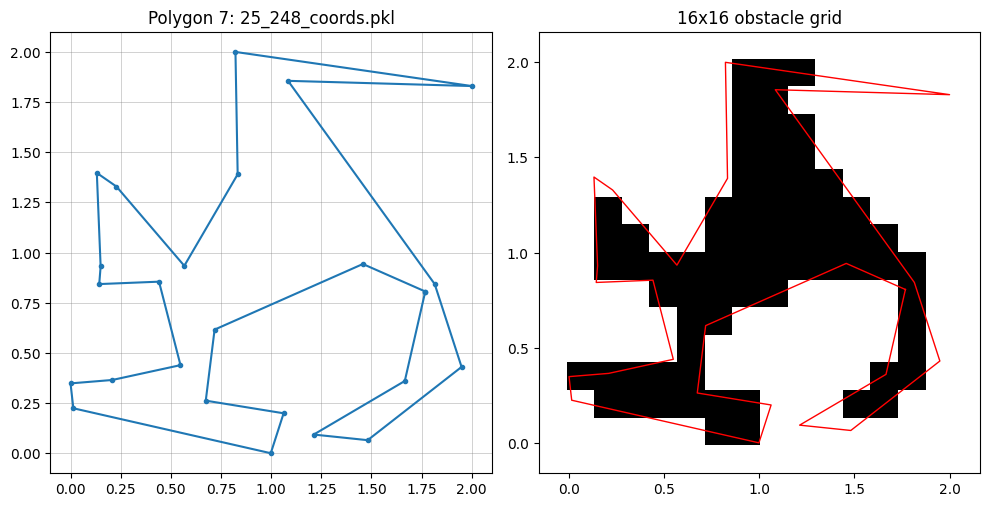

In [362]:
polygon_index = np.random.randint(0, len(test_batch2))
print(f"Randomly selected polygon index: {polygon_index}")
k = list(test_batch2.keys())[polygon_index]
polygon = test_batch2[k]["level_2_polygon"]

grid_64, extent_64, fill_64 = polygon_to_obstacle_grid(polygon, grid_shape=(64, 64), samples_per_cell=8)
grid_16, extent_16, fill_16 = polygon_to_obstacle_grid(polygon, grid_shape=(16, 16), samples_per_cell=8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

closed_polygon = np.vstack([polygon, polygon[0]])
axes[0].plot(closed_polygon[:, 0], closed_polygon[:, 1], "-o", markersize=3)
axes[0].set_title(f"Polygon {polygon_index}: {k}")
axes[0].set_aspect("equal")
# axes[0].grid(True, alpha=0.3)
axes[0].grid(True, which='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# axes[1].imshow(grid_64, cmap="gray", origin="upper", extent=extent_64, interpolation="nearest")
# axes[1].plot(closed_polygon[:, 0], closed_polygon[:, 1], "r-", linewidth=1)
# axes[1].set_title("64x64 obstacle grid")
# axes[1].set_aspect("equal")

axes[1].imshow(grid_16, cmap="gray", origin="upper", extent=extent_16, interpolation="nearest")
axes[1].plot(closed_polygon[:, 0], closed_polygon[:, 1], "r-", linewidth=1)
axes[1].set_title("16x16 obstacle grid")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()


Randomly selected polygon index: 120


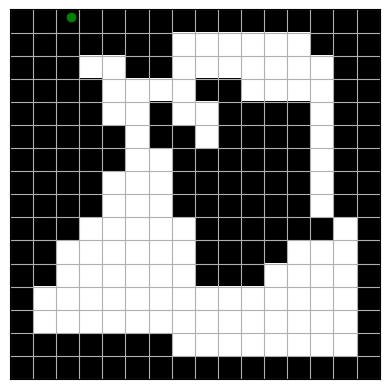

In [244]:
polygon_index = np.random.randint(len(d0))
print(f"Randomly selected polygon index: {polygon_index}")
k = list(d0.keys())[polygon_index]
polygon = d0[k]["level_2_polygon"]

grid_16, extent_16, fill_16 = polygon_to_obstacle_grid(polygon, grid_shape=(16, 16), samples_per_cell=8)
plot_grid(grid_16, extent_16)